Found 503 records for CAPITL


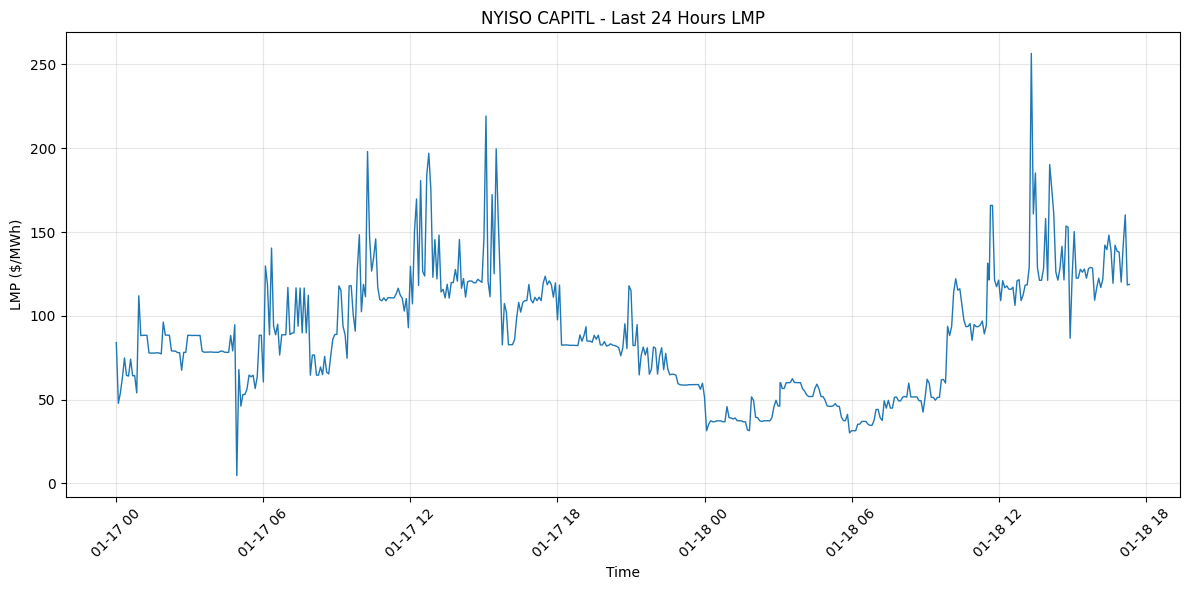


LMP Statistics for CAPITL:
Mean: $88.67/MWh
Min: $4.67/MWh
Max: $256.57/MWh


In [13]:
import gridstatus
import pandas as pd
import matplotlib.pyplot as plt

# Initialize NYISO
nyiso = gridstatus.NYISO()

# Pull last 24 hours of real-time price data
prices = nyiso.get_lmp(
    date=pd.Timestamp.now(tz='US/Eastern') - pd.Timedelta(hours=24),
    end=pd.Timestamp.now(tz='US/Eastern'),
    market="REAL_TIME_5_MIN"
)

# Filter for CAPITL location
prices_filtered = prices[prices['Location'] == 'CAPITL']

# Sort by time to ensure proper plotting
prices_filtered = prices_filtered.sort_values('Time')

print(f"Found {len(prices_filtered)} records for CAPITL")

# Create the plot
plt.figure(figsize=(12, 6))
plt.plot(prices_filtered['Time'], prices_filtered['LMP'], linewidth=1)
plt.xlabel('Time')
plt.ylabel('LMP ($/MWh)')
plt.title('NYISO CAPITL - Last 24 Hours LMP')
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Optional: Print summary statistics
print(f"\nLMP Statistics for CAPITL:")
print(f"Mean: ${prices_filtered['LMP'].mean():.2f}/MWh")
print(f"Min: ${prices_filtered['LMP'].min():.2f}/MWh")
print(f"Max: ${prices_filtered['LMP'].max():.2f}/MWh")

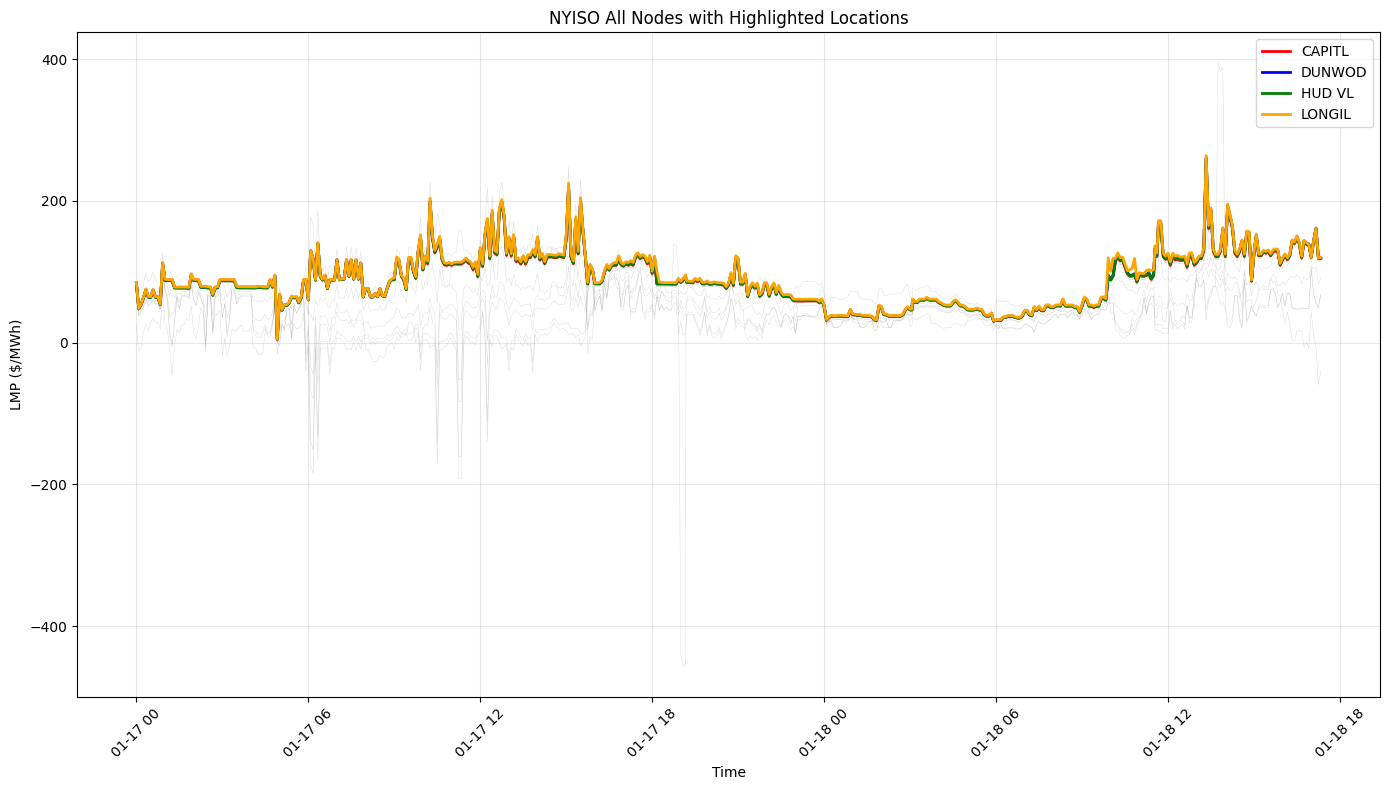

In [14]:
# Plot all nodes in gray, then highlight specific ones
fig, ax = plt.subplots(figsize=(14, 8))

# Plot all nodes in gray
for location in prices['Location'].unique():
    location_data = prices[prices['Location'] == location]
    ax.plot(location_data['Time'], location_data['LMP'], 
            color='gray', linewidth=0.3, alpha=0.3)

# Highlight specific nodes
highlight_nodes = ['CAPITL', 'DUNWOD', 'HUD VL', 'LONGIL']
colors = ['red', 'blue', 'green', 'orange']

for node, color in zip(highlight_nodes, colors):
    node_data = prices[prices['Location'] == node]
    if len(node_data) > 0:
        ax.plot(node_data['Time'], node_data['LMP'], 
                color=color, linewidth=2, label=node)

ax.set_xlabel('Time')
ax.set_ylabel('LMP ($/MWh)')
ax.set_title('NYISO All Nodes with Highlighted Locations')
ax.grid(True, alpha=0.3)
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Fetching data...
Data fetched! Total records: 376730
Available columns: ['Time', 'Interval Start', 'Interval End', 'Market', 'Location', 'Location Type', 'LMP', 'Energy', 'Congestion', 'Loss']
Unique locations: 746

Found 505 records for Cherry Street
Cherry Street locations found: ['CHERRYST_13_KV_LD']


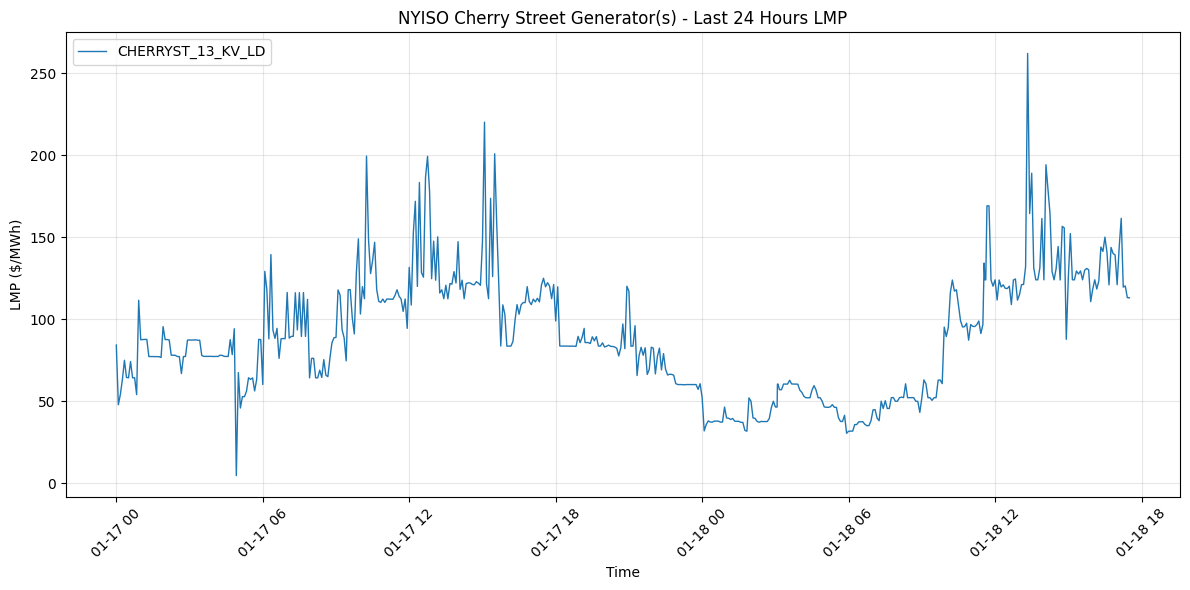


LMP Statistics for Cherry Street:
Mean: $89.58/MWh
Min: $4.65/MWh
Max: $261.96/MWh


In [18]:
import gridstatus
import pandas as pd
import matplotlib.pyplot as plt

# Initialize NYISO
nyiso = gridstatus.NYISO()

print(f"Fetching data...")

# Pull generator-level data
prices_nodes = nyiso.get_lmp(
    date=pd.Timestamp.now(tz='US/Eastern') - pd.Timedelta(hours=24),
    end=pd.Timestamp.now(tz='US/Eastern'),
    market="REAL_TIME_5_MIN",
    location_type="generator"
)

print(f"Data fetched! Total records: {len(prices_nodes)}")
print(f"Available columns: {prices_nodes.columns.tolist()}")
print(f"Unique locations: {prices_nodes['Location'].nunique()}")

# Filter for Cherry Street nodes - just search by name
cherry_st = prices_nodes[prices_nodes["Location"].str.contains("CHERRYST", na=False, case=False)]

if len(cherry_st) == 0:
    print("\nNo Cherry Street data found. Searching for similar names:")
    cherry_locations = prices_nodes[prices_nodes["Location"].str.contains("CHERRY", na=False, case=False)]["Location"].unique()
    print(f"Found {len(cherry_locations)} locations with 'CHERRY':")
    print(cherry_locations)
else:
    # Sort by time
    cherry_st = cherry_st.sort_values('Time')
    print(f"\nFound {len(cherry_st)} records for Cherry Street")
    print(f"Cherry Street locations found: {cherry_st['Location'].unique()}")
    
    # Plot Cherry Street prices
    plt.figure(figsize=(12, 6))
    
    # If multiple Cherry Street locations, plot each separately
    for location in cherry_st['Location'].unique():
        loc_data = cherry_st[cherry_st['Location'] == location]
        plt.plot(loc_data['Time'], loc_data['LMP'], linewidth=1, label=location)
    
    plt.xlabel('Time')
    plt.ylabel('LMP ($/MWh)')
    plt.title('NYISO Cherry Street Generator(s) - Last 24 Hours LMP')
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
    
    # Print summary statistics
    print(f"\nLMP Statistics for Cherry Street:")
    print(f"Mean: ${cherry_st['LMP'].mean():.2f}/MWh")
    print(f"Min: ${cherry_st['LMP'].min():.2f}/MWh")
    print(f"Max: ${cherry_st['LMP'].max():.2f}/MWh")